# stc tv | Task 1: Viewer behavior and streaming quality

**Objective.** Compare movie and series viewing, identify SD and HD viewing patterns, and summarize the results with reproducible Python code. Each row represents one viewing event.

**Data source.** `stc TV Data Set_T1.xlsb`, sheet `Final_Dataset`, supplied with the virtual work experience. Run this notebook in Google Colab or Jupyter. If the Excel file is not beside the notebook, the loading cell asks for an upload in Colab.

## 1. Load the data and check its shape

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    import pyxlsb
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyxlsb'])

DATA_FILE = Path('stc TV Data Set_T1.xlsb')
if not DATA_FILE.exists():
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(f'Place {DATA_FILE.name} beside this notebook.') from exc
    print(f'Please upload {DATA_FILE.name}.')
    files.upload()

if not DATA_FILE.exists():
    raise FileNotFoundError(f'{DATA_FILE.name} was not uploaded.')

raw = pd.read_excel(DATA_FILE, sheet_name='Final_Dataset', engine='pyxlsb')
print(f'Rows: {raw.shape[0]:,}; columns: {raw.shape[1]}')
display(raw.head())

Rows: 1,048,575; columns: 13


,Column1,date_,user_id_maped,program_name,duration_seconds,program_class,season,episode,program_desc,program_genre,series_title,hd,original_name
0,1,42882,26138,100 treets,40,MOVIE,0,0,Drama Movie100 Streets,Drama,0,0,100 treets
1,3,42876,7946,Moana,17,MOVIE,0,0,Animation MovieMoana (HD),Animation,0,1,Moana
2,4,42957,7418,The Mermaid Princess,8,MOVIE,0,0,Animation MovieThe Mermaid Princess (HD),Animation,0,1,The Mermaid Princess
3,5,42942,19307,The Mermaid Princess,76,MOVIE,0,0,Animation MovieThe Mermaid Princess (HD),Animation,0,1,The Mermaid Princess
4,7,42923,15860,Churchill,87,MOVIE,0,0,Biography MovieChurchill (HD),Biography,0,1,Churchill


## 2. Clean the data and check missing values

The workbook has an extra index column. The only missing values are in `program_desc`; replace them with a clear label rather than hiding them by converting the column to a string. Keep user IDs as identifiers, and read the Excel date serials as dates. Identical records after removing the source index are retained: there is no separate event ID to establish whether they are erroneous duplicates or repeated views.

In [2]:
missing_before = raw.isna().sum()
print('Missing values before cleaning:')
display(missing_before[missing_before > 0].rename('missing_rows').to_frame())

df = raw.drop(columns=['Column1']).copy()
del raw
df['program_name'] = df['program_name'].str.strip()
df['program_class'] = df['program_class'].str.strip()
df['program_desc'] = df['program_desc'].fillna('Not provided')
df['date_'] = pd.to_datetime(df['date_'], unit='D', origin='1899-12-30')
numeric_columns = ['duration_seconds', 'season', 'episode', 'series_title', 'hd']
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

missing_after = df.isna().sum()
print(f'Missing values after cleaning: {missing_after.sum():,}')
print(f'Identical rows after removing the source index (retained): {df.duplicated().sum():,}')
assert missing_after.sum() == 0
assert set(df['program_class'].unique()) == {'MOVIE', 'SERIES/EPISODES'}
assert set(df['hd'].unique()) == {0, 1}
display(df.head())

Missing values before cleaning:


,missing_rows
program_desc,14038


Missing values after cleaning: 0


Identical rows after removing the source index (retained): 102,074


,date_,user_id_maped,program_name,duration_seconds,program_class,season,episode,program_desc,program_genre,series_title,hd,original_name
0,2017-05-27,26138,100 treets,40,MOVIE,0,0,Drama Movie100 Streets,Drama,0,0,100 treets
1,2017-05-21,7946,Moana,17,MOVIE,0,0,Animation MovieMoana (HD),Animation,0,1,Moana
2,2017-08-10,7418,The Mermaid Princess,8,MOVIE,0,0,Animation MovieThe Mermaid Princess (HD),Animation,0,1,The Mermaid Princess
3,2017-07-26,19307,The Mermaid Princess,76,MOVIE,0,0,Animation MovieThe Mermaid Princess (HD),Animation,0,1,The Mermaid Princess
4,2017-07-07,15860,Churchill,87,MOVIE,0,0,Biography MovieChurchill (HD),Biography,0,1,Churchill


## 3. Describe the numerical columns

The table reports the required count, mean, standard deviation, minimum, and maximum. `hd` is a binary indicator (0 = SD, 1 = HD), so its mean is the overall HD share. User IDs and dates are excluded because their averages have no useful viewing interpretation.

In [3]:
numeric_summary = df[numeric_columns].describe().loc[['count', 'mean', 'std', 'min', 'max']]
display(numeric_summary.round(2))
print(f"Median viewing duration: {df['duration_seconds'].median():,.0f} seconds")

,duration_seconds,season,episode,series_title,hd
count,1048575.00,1048575.00,1048575.00,1048575.00,1048575.00
mean,1230.96,1.34,6.16,0.01,0.39
std,6821.06,2.10,12.22,0.11,0.49
min,2.00,0.00,0.00,0.00,0.00
max,1461329.00,23.00,282.00,1.00,1.00


Median viewing duration: 119 seconds


## 4. Compare movies and series

Useful measures are viewing events, distinct viewers, total watch hours, and the median event duration. A viewer can watch both classes, so distinct-viewer counts by class should not be added together.

,viewing_events,distinct_viewers,median_event_seconds,watch_hours,event_share_pct,watch_hours_share_pct
program_class,,,,,,
MOVIE,488401,11355,77.0,103444.15,46.58,28.85
SERIES/EPISODES,560174,3901,1133.0,255097.79,53.42,71.15


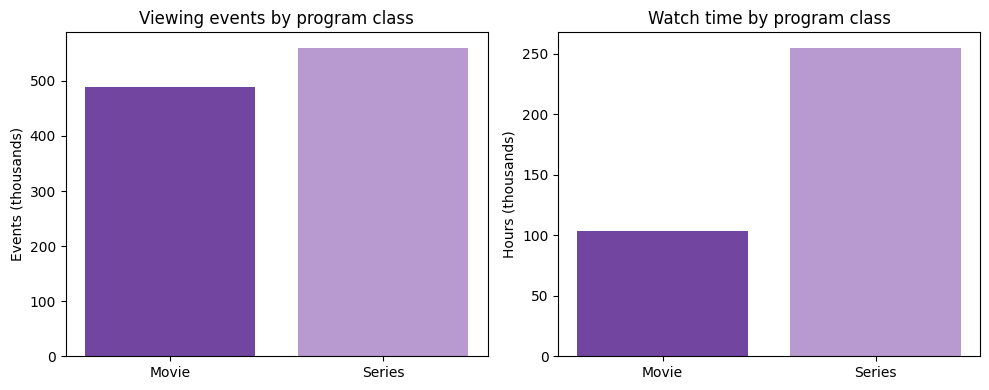

In [4]:
class_summary = (df.groupby('program_class')
                 .agg(viewing_events=('user_id_maped', 'size'),
                      distinct_viewers=('user_id_maped', 'nunique'),
                      watch_seconds=('duration_seconds', 'sum'),
                      median_event_seconds=('duration_seconds', 'median')))
class_summary['watch_hours'] = class_summary.pop('watch_seconds') / 3600
class_summary['event_share_pct'] = 100 * class_summary['viewing_events'] / len(df)
class_summary['watch_hours_share_pct'] = (100 * class_summary['watch_hours']
                                         / class_summary['watch_hours'].sum())
display(class_summary.round(2))

labels = ['Movie', 'Series']
ordered = class_summary.loc[['MOVIE', 'SERIES/EPISODES']]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, ordered['viewing_events'] / 1000, color=['#7145A0', '#B89AD0'])
axes[0].set_title('Viewing events by program class')
axes[0].set_ylabel('Events (thousands)')
axes[1].bar(labels, ordered['watch_hours'] / 1000, color=['#7145A0', '#B89AD0'])
axes[1].set_title('Watch time by program class')
axes[1].set_ylabel('Hours (thousands)')
plt.tight_layout()
plt.show()

## 5. Compare SD and HD viewing

Compare quality **within each program class**. This avoids mistaking a difference in the movie/series mix for a quality preference. The HD and SD percentages below are based on viewing events, not on distinct users.

hd,SD events,HD events,SD share %,HD share %
program_class,,,,
MOVIE,156655,331746,32.08,67.92
SERIES/EPISODES,486884,73290,86.92,13.08


hd,SD hours,HD hours
program_class,,
MOVIE,38587.78,64856.37
SERIES/EPISODES,229776.59,25321.19


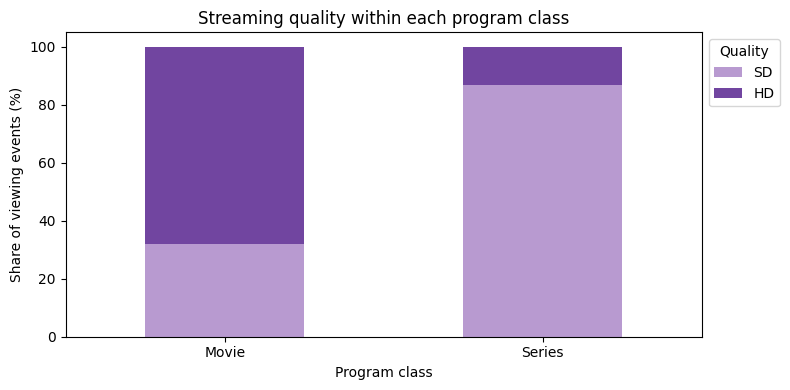

In [5]:
quality_counts = pd.crosstab(df['program_class'], df['hd'])
quality_counts = quality_counts.rename(columns={0: 'SD events', 1: 'HD events'})
quality_counts['SD share %'] = 100 * quality_counts['SD events'] / quality_counts.sum(axis=1)
quality_counts['HD share %'] = 100 - quality_counts['SD share %']
display(quality_counts.round(2))

quality_hours = (df.groupby(['program_class', 'hd'])['duration_seconds']
                   .sum().unstack(fill_value=0) / 3600)
quality_hours = quality_hours.rename(columns={0: 'SD hours', 1: 'HD hours'})
display(quality_hours.round(2))

plot_data = quality_counts.loc[['MOVIE', 'SERIES/EPISODES']]
ax = plot_data[['SD share %', 'HD share %']].plot.bar(
    stacked=True, color=['#B89AD0', '#7145A0'], figsize=(8, 4))
ax.set_xticklabels(['Movie', 'Series'], rotation=0)
ax.set_title('Streaming quality within each program class')
ax.set_ylabel('Share of viewing events (%)')
ax.set_xlabel('Program class')
ax.legend(['SD', 'HD'], title='Quality', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## 6. Identify viewer segments and their usual quality

Classify each viewer as *Movie only*, *Series only*, or *Both*. Then label the viewer *Mostly HD* or *Mostly SD* if more than half of their events use that quality; an equal number is a *Tie*. This user-level view answers which types of viewers usually use SD or HD.

quality_preference,Mostly SD,Mostly HD,Tie,Total viewers,Mostly SD %,Mostly HD %
viewer_segment,,,,,,
Movie only,988,6480,209,7677,12.87,84.41
Series only,163,56,4,223,73.09,25.11
Both,2057,1528,93,3678,55.93,41.54


Total distinct viewers: 11,578


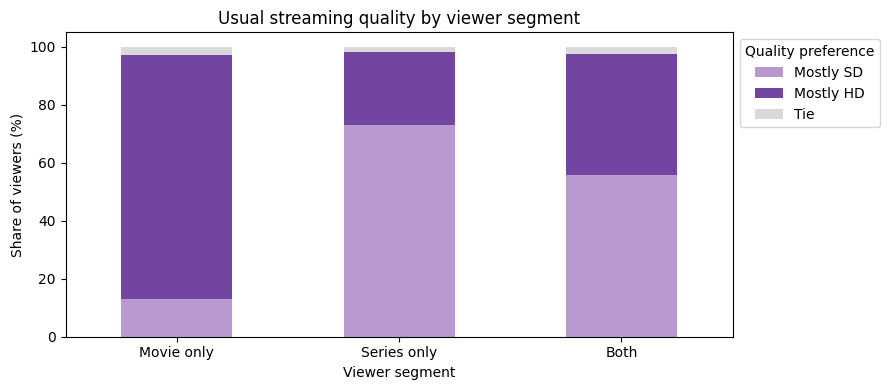

In [6]:
user_classes = pd.crosstab(df['user_id_maped'], df['program_class'])
movie = user_classes['MOVIE'] > 0
series = user_classes['SERIES/EPISODES'] > 0
segments = pd.Series(
    np.select([movie & series, movie, series],
              ['Both', 'Movie only', 'Series only'], default='Unknown'),
    index=user_classes.index, name='viewer_segment')

user_quality = pd.crosstab(df['user_id_maped'], df['hd']).reindex(
    columns=[0, 1], fill_value=0)
preferences = pd.Series(
    np.select([user_quality[1] > user_quality[0],
               user_quality[0] > user_quality[1]],
              ['Mostly HD', 'Mostly SD'], default='Tie'),
    index=user_quality.index, name='quality_preference')
viewer_summary = pd.crosstab(segments, preferences).reindex(
    index=['Movie only', 'Series only', 'Both'],
    columns=['Mostly SD', 'Mostly HD', 'Tie'], fill_value=0)
viewer_summary['Total viewers'] = viewer_summary.sum(axis=1)
viewer_summary['Mostly SD %'] = (100 * viewer_summary['Mostly SD']
                                 / viewer_summary['Total viewers'])
viewer_summary['Mostly HD %'] = (100 * viewer_summary['Mostly HD']
                                 / viewer_summary['Total viewers'])
display(viewer_summary.round(2))
print(f'Total distinct viewers: {len(user_quality):,}')

share = viewer_summary[['Mostly SD', 'Mostly HD', 'Tie']].div(
    viewer_summary['Total viewers'], axis=0) * 100
ax = share.plot.bar(stacked=True, color=['#B89AD0', '#7145A0', '#D9D9D9'],
                    figsize=(9, 4))
ax.set_title('Usual streaming quality by viewer segment')
ax.set_ylabel('Share of viewers (%)')
ax.set_xlabel('Viewer segment')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Quality preference', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## 7. Findings and recommendation

- The data contain **1,048,575 viewing events** from **11,578 distinct viewers**. After replacing 14,038 missing program descriptions with `Not provided`, no cells remain missing.
- Series account for **53.42% of events** and **71.15% of watch hours**. Movies account for **46.58% of events**. The class-level viewer counts overlap because some people watch both.
- **67.92% of movie events** are HD, compared with **13.08% of series events**. Series viewing is therefore predominantly SD in this dataset.
- Among **7,677 movie-only viewers**, **84.41%** are mostly HD. Among **3,678 viewers of both classes**, **55.93%** are mostly SD. Among **223 series-only viewers**, **73.09%** are mostly SD.
- **Recommendation:** Review HD availability and playback conditions for series first, then check whether device type, connection speed, or content availability explains the gap. Those causes cannot be established from this dataset alone.

**Interpretation note.** The mean event duration is about 1,231 seconds, but its median is 119 seconds and the maximum is 1,461,329 seconds. The distribution is highly skewed, so median duration is more representative of a typical event. The workbook contains exactly the maximum number of data rows in one Excel sheet; the analysis describes the supplied sheet and may not cover all historical viewing.